Loading weights: 100%|██████████| 310/310 [00:00<00:00, 9714.99it/s]


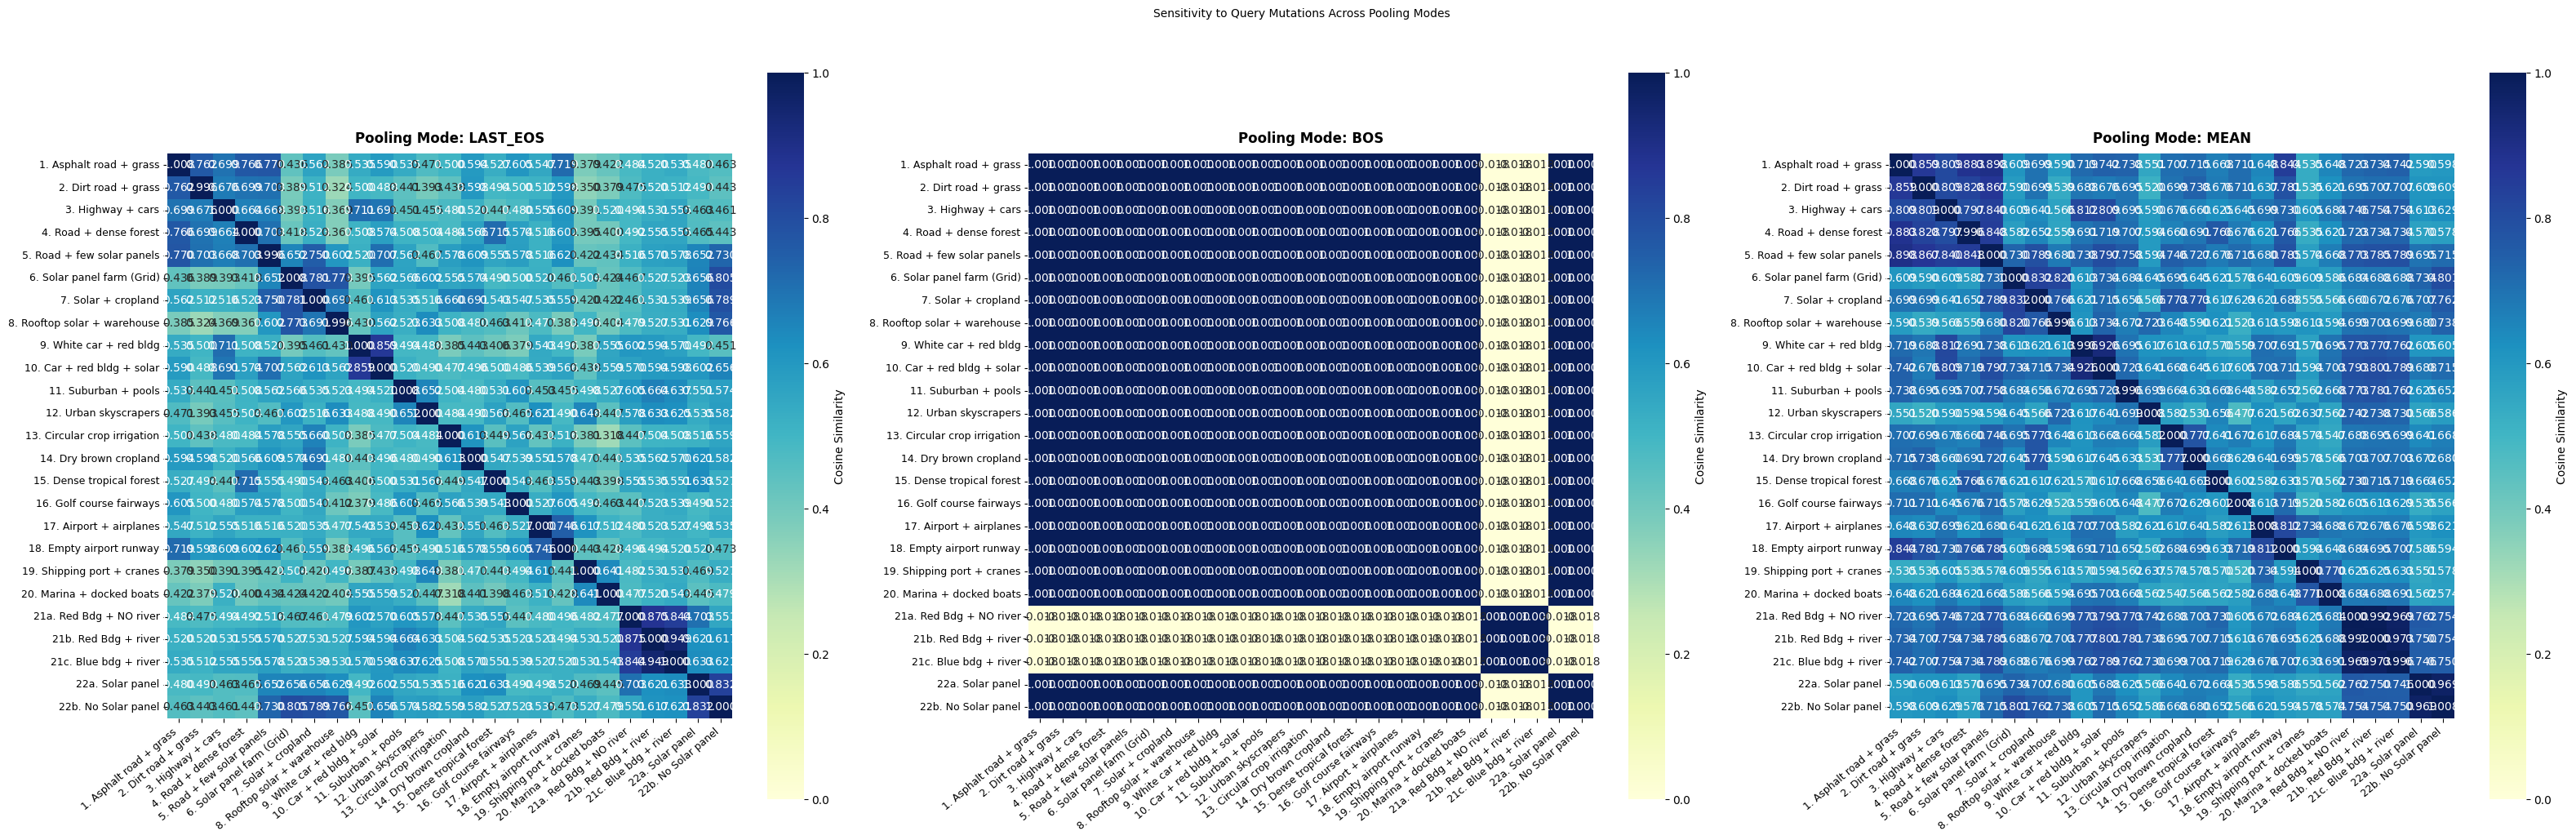

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional

# -------------------------------------------------------------------
# 1. Flexible Pooling Module
# -------------------------------------------------------------------
class AttentionPool(nn.Module):
    def __init__(self, hidden_size: int):
        super().__init__()
        self.attn = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, last_hidden_states: Tensor, attention_mask: Tensor) -> Tensor:
        logits = self.attn(last_hidden_states).squeeze(-1)
        logits = logits.masked_fill(attention_mask == 0, float("-inf"))
        weights = F.softmax(logits, dim=-1).unsqueeze(-1)
        return (last_hidden_states * weights).sum(dim=1)


def pool_tokens(
    last_hidden_states: Tensor,
    attention_mask: Tensor,
    pooling_mode: str = "last_eos",
    attn_pool_module: Optional[nn.Module] = None,
) -> Tensor:
    mode = pooling_mode.lower()

    if mode in ("first_eos", "bos", "cls"):
        return last_hidden_states[:, 0]

    elif mode in ("last_eos", "eos"):
        left_padding = (attention_mask[:, -1].sum() == attention_mask.shape[0])
        if left_padding:
            return last_hidden_states[:, -1]
        else:
            sequence_lengths = attention_mask.sum(dim=1) - 1
            batch_size = last_hidden_states.shape[0]
            return last_hidden_states[
                torch.arange(batch_size, device=last_hidden_states.device), sequence_lengths
            ]

    elif mode == "mean":
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_states.size()).to(last_hidden_states.dtype)
        sum_embeddings = torch.sum(last_hidden_states * input_mask_expanded, dim=1)
        sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        return sum_embeddings / sum_mask

    elif mode == "attention":
        if attn_pool_module is None:
            raise ValueError("`attn_pool_module` must be provided when pooling_mode='attention'.")
        return attn_pool_module(last_hidden_states, attention_mask)

    else:
        raise ValueError(f"Unsupported pooling mode '{pooling_mode}'.")


# -------------------------------------------------------------------
# 2. Curated Aerial Imagery Queries (Structured Mutations)
# -------------------------------------------------------------------
# Prompts organized to test object addition/removal & subtle attribute shifts
input_texts = [
    # --- Cluster 1: Infrastructure & Roads (Minimal Mutations) ---
    "A asphalt road surrounded by a small green grass area",                   # 1. Base
    "A two-lane dirt road cutting through a small grassy area",                # 2. Surface material mutation
    "A highway with white cars driving past a small green area",              # 3. Object addition (moving cars)
    "A road surrounded by a dense green forest",                               # 4. Surroundings mutation (grass -> forest)
    
    # --- Cluster 2: Solar & Energy Infrastructure ---
    "A road and a small green area with a few solar panels",                   # 5. Low-density solar addition
    "A large commercial solar panel farm with regular rectangular grid layout", # 6. High-density solar farm
    "A solar panel field adjacent to an agricultural cropland field",          # 7. Agricultural context shift
    "Rooftop solar panels installed on top of industrial warehouse buildings",# 8. Urban roof solar shift

    # --- Cluster 3: Residential & Urban ---
    "A white car parked near a single red residential building",               # 9. Single building base
    "A white car parked near a red building with solar panels and greenery",   # 10. Multi-object combination
    "A dense suburban neighborhood with red roofs and swimming pools",         # 11. Scale/density mutation
    "A high-rise commercial city center with dense skyscrapers",               # 12. Distinct urban class

    # --- Cluster 4: Agriculture & Vegetation ---
    "A green agricultural field with center-pivot circular irrigation",        # 13. Circular crop pattern
    "Dry brown agricultural land with harvested crop rows",                    # 14. Seasonal/color mutation
    "A dense tropical forest canopy with no visible human infrastructure",     # 15. Pure natural environment
    "A golf course with green fairways, sand traps, and water ponds",          # 16. Managed recreational greenery

    # --- Cluster 5: Aviation & Maritime Infrastructure ---
    "A commercial airport runway with parked passenger airplanes",            # 17. Airport base
    "An empty paved airport runway surrounded by grass clear zones",           # 18. Airport minus planes
    "A busy shipping port with container ships, cranes, and storage yards",    # 19. Port infrastructure
    "A marina with white boats moored at docks along a coastline",              # 20. Small vessel maritime

    # --- Cluster 6: Yes vs No ---
    "This image gas a red building and a few white tents, but no river",
    "This image gas a red building and a few white tents, and a river",
    "This image gas a blue building and a few white tents, and a river",
    "This image has no solar panels",
    "This image has solar panels",
]

labels = [
    "1. Asphalt road + grass",
    "2. Dirt road + grass",
    "3. Highway + cars",
    "4. Road + dense forest",
    "5. Road + few solar panels",
    "6. Solar panel farm (Grid)",
    "7. Solar + cropland",
    "8. Rooftop solar + warehouse",
    "9. White car + red bldg",
    "10. Car + red bldg + solar",
    "11. Suburban + pools",
    "12. Urban skyscrapers",
    "13. Circular crop irrigation",
    "14. Dry brown cropland",
    "15. Dense tropical forest",
    "16. Golf course fairways",
    "17. Airport + airplanes",
    "18. Empty airport runway",
    "19. Shipping port + cranes",
    "20. Marina + docked boats",
    "21a. Red Bdg + NO river",
    "21b. Red Bdg + river",
    "21c. Blue bdg + river",
    "22a. Solar panel",
    "22b. No Solar panel"
]

# -------------------------------------------------------------------
# 3. Model Initialization
# -------------------------------------------------------------------
model_id = 'Qwen/Qwen3-Embedding-0.6B'
tokenizer = AutoTokenizer.from_pretrained(model_id, padding_side='left')
model = AutoModel.from_pretrained(model_id)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)
model.eval()

# -------------------------------------------------------------------
# 4. Tokenization & Single Forward Pass
# -------------------------------------------------------------------
max_length = 8192
batch_dict = tokenizer(
    input_texts,
    padding=True,
    truncation=True,
    max_length=max_length,
    return_tensors="pt",
).to(device)

with torch.no_grad():
    outputs = model(**batch_dict)

# -------------------------------------------------------------------
# 5. Compute Similarities for Multiple Pooling Modes
# -------------------------------------------------------------------
pooling_modes = ["last_eos", "bos", "mean"]
matrices = {}

for mode in pooling_modes:
    # Compute representations for current pooling mode
    emb = pool_tokens(outputs.last_hidden_state, batch_dict['attention_mask'], pooling_mode=mode)
    emb = F.normalize(emb, p=2, dim=1)
    
    # Compute similarity matrix (casting float32 for numpy safety)
    sim = (emb @ emb.T).float().cpu().numpy()
    matrices[mode] = sim

# -------------------------------------------------------------------
# 6. Plot Side-by-Side Comparative EDA Heatmaps
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(32, 10))

for ax, mode in zip(axes, pooling_modes):
    sns.heatmap(
        matrices[mode],
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        xticklabels=labels,
        yticklabels=labels,
        cbar_kws={'label': 'Cosine Similarity'},
        vmin=0.0,
        vmax=1.0,
        ax=ax,
        square=True
    )
    ax.set_title(f"Pooling Mode: {mode.upper()}", fontsize=12, fontweight='bold', pad=10)
    ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=9)
    ax.set_yticklabels(labels, rotation=0, fontsize=9)

plt.suptitle("Qwen3", fontsize=15, fontweight='bold', y=1.02)
plt.suptitle("Sensitivity to Query Mutations Across Pooling Modes", fontsize=10, y=1.03)
plt.tight_layout()
plt.show()

In [18]:
emb.shape

torch.Size([20, 4096])

In [26]:
import re
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

# Download NLTK sentence splitter point data if needed
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)


# -------------------------------------------------------------------
# 1. Pooling Helper Function
# -------------------------------------------------------------------
def pool_tokens(
    last_hidden_states: torch.Tensor,
    attention_mask: torch.Tensor,
    pooling_mode: str = "last_eos",
) -> torch.Tensor:
    mode = pooling_mode.lower()

    if mode in ("bos", "cls", "first_eos"):
        return last_hidden_states[:, 0]

    elif mode in ("last_eos", "eos"):
        left_padding = (attention_mask[:, -1].sum() == attention_mask.shape[0])
        if left_padding:
            return last_hidden_states[:, -1]
        else:
            sequence_lengths = attention_mask.sum(dim=1) - 1
            batch_size = last_hidden_states.shape[0]
            return last_hidden_states[
                torch.arange(batch_size, device=last_hidden_states.device), sequence_lengths
            ]

    elif mode == "mean":
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_states.size()).to(last_hidden_states.dtype)
        sum_embeddings = torch.sum(last_hidden_states * input_mask_expanded, dim=1)
        sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        return sum_embeddings / sum_mask

    else:
        raise ValueError(f"Unsupported pooling mode '{pooling_mode}'.")


# -------------------------------------------------------------------
# 2. Text Preprocessing & Sentence Extraction
# -------------------------------------------------------------------
def extract_sentences(multiline_text: str) -> list[str]:
    """Cleans line breaks and splits multiline captions into distinct sentences."""
    lines = [line.strip() for line in multiline_text.strip().split('\n') if line.strip()]
    sentences = []
    
    for line in lines:
        sents = nltk.sent_tokenize(line)
        for s in sents:
            s_clean = re.sub(r'\s+', ' ', s).strip()
            if len(s_clean) > 5:
                sentences.append(s_clean)
                
    return sentences


# -------------------------------------------------------------------
# 3. Model Pipeline Setup
# -------------------------------------------------------------------
model_id = 'Qwen/Qwen3-Embedding-8B'
tokenizer = AutoTokenizer.from_pretrained(model_id, padding_side='left')
model = AutoModel.from_pretrained(model_id)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)
model.eval()


# -------------------------------------------------------------------
# 4. Parquet Sampling & Embedding Analysis
# -------------------------------------------------------------------
def analyze_parquet_captions(
    parquet_path: str,
    caption_column: str = "caption",
    num_samples: int = 3,
    random_state: int = 42
):
    df = pd.read_parquet(parquet_path)
    
    # Filter out empty or non-multiline entries
    valid_df = df[df[caption_column].astype(str).str.contains('\n', na=False)].dropna(subset=[caption_column])
    
    if len(valid_df) == 0:
        print("No multiline captions found in Parquet column. Sampling randomly instead...")
        valid_df = df.dropna(subset=[caption_column])
        
    sampled_captions = valid_df[caption_column].sample(n=min(num_samples, len(valid_df)), random_state=random_state).tolist()

    pooling_modes = ["last_eos", "bos", "mean"]

    for idx, full_caption in enumerate(sampled_captions):
        sentences = extract_sentences(full_caption)
        
        if not sentences:
            continue

        clean_full_caption = re.sub(r'\s+', ' ', full_caption).strip()
        input_texts = [clean_full_caption] + sentences

        y_labels = ["FULL CAPTION"] + [f"S{i+1}: {s[:35]}..." if len(s) > 35 else f"S{i+1}: {s}" for i, s in enumerate(sentences)]
        x_labels = ["FULL"] + [f"S{i+1}" for i in range(len(sentences))]

        batch_dict = tokenizer(
            input_texts,
            padding=True,
            truncation=True,
            max_length=8192,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**batch_dict)

        # Create figure with extra bottom space for the caption text box
        fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

        for ax, mode in zip(axes, pooling_modes):
            emb = pool_tokens(outputs.last_hidden_state, batch_dict['attention_mask'], pooling_mode=mode)
            emb = F.normalize(emb, p=2, dim=1)
            
            sim_matrix = (emb @ emb.T).float().cpu().numpy()

            sns.heatmap(
                sim_matrix,
                annot=True,
                fmt=".3f",
                cmap="Blues",
                xticklabels=x_labels,
                yticklabels=y_labels if ax == axes[0] else x_labels,
                cbar_kws={'label': 'Cosine Similarity'},
                vmin=0.0,
                vmax=1.0,
                ax=ax,
                square=True
            )
            ax.set_title(f"Mode: {mode.upper()}", fontsize=11, fontweight='bold')
            ax.set_xticklabels(x_labels, rotation=0, fontsize=9)
            ax.set_yticklabels(y_labels if ax == axes[0] else x_labels, rotation=0, fontsize=8)

        plt.suptitle(
            f"Sample #{idx+1} — Sentence-to-Full Cross-Similarity Breakdown",
            fontsize=13,
            fontweight='bold',
            y=1.02
        )

        # -------------------------------------------------------------------
        # Add Full Caption at the bottom of the figure
        # -------------------------------------------------------------------
        formatted_caption = "\n".join([f"• {s}" for s in sentences])
        caption_box_text = f"Full Caption:\n{formatted_caption}"

        fig.text(
            0.5, -0.15, caption_box_text,
            ha='center', va='top', fontsize=10, style='italic',
            bbox=dict(boxstyle='round,pad=0.6', facecolor='#f8f9fa', edgecolor='#cccccc', alpha=1.0)
        )

        plt.tight_layout()
        plt.show()


/data/susanket/conda/lib/python3.13/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/susanket/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 10293.34it/s]


In [ ]:

# -------------------------------------------------------------------
# 5. Usage Example
# -------------------------------------------------------------------
# Replace with your actual parquet filepath and caption column name:
analyze_parquet_captions("/data/susanket/vlm/images2/tbd-cap.parquet", caption_column="dense_caption", num_samples=10)

In [28]:
import re
import random
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

# Ensure NLTK sentence splitter data is available
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)


# -------------------------------------------------------------------
# 1. Pooling Helper Function
# -------------------------------------------------------------------
def pool_tokens(
    last_hidden_states: torch.Tensor,
    attention_mask: torch.Tensor,
    pooling_mode: str = "last_eos",
) -> torch.Tensor:
    mode = pooling_mode.lower()

    if mode in ("bos", "cls", "first_eos"):
        return last_hidden_states[:, 0]

    elif mode in ("last_eos", "eos"):
        left_padding = (attention_mask[:, -1].sum() == attention_mask.shape[0])
        if left_padding:
            return last_hidden_states[:, -1]
        else:
            sequence_lengths = attention_mask.sum(dim=1) - 1
            batch_size = last_hidden_states.shape[0]
            return last_hidden_states[
                torch.arange(batch_size, device=last_hidden_states.device), sequence_lengths
            ]

    elif mode == "mean":
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_states.size()).to(last_hidden_states.dtype)
        sum_embeddings = torch.sum(last_hidden_states * input_mask_expanded, dim=1)
        sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        return sum_embeddings / sum_mask

    else:
        raise ValueError(f"Unsupported pooling mode '{pooling_mode}'.")


# -------------------------------------------------------------------
# 2. Perturbation & Text Mutation Logic
# -------------------------------------------------------------------
MUTATION_RULES = [
    # (Regex pattern, Replacement, Description)
    (r"\bred\b", "blue", "Color Swap (red → blue)"),
    (r"\bwhite\b", "black", "Color Swap (white → black)"),
    (r"\bwith solar panels\b", "without solar panels", "Attribute Negation (solar → no solar)"),
    (r"\bsolar panel field\b", "agricultural cropland field", "Domain Shift (solar field → cropland)"),
    (r"\bgreen area\b", "dry desert area", "Landcover Mutation (green area → desert)"),
    (r"\bcar\b", "truck", "Vehicle Mutation (car → truck)"),
    (r"\bairplanes\b", "helicopters", "Aircraft Mutation (airplanes → helicopters)"),
]

def generate_mutations(full_caption: str) -> list[tuple[str, str]]:
    """
    Generates perturbed versions of the caption using pre-defined aerial mutation rules.
    Returns a list of (mutated_text, mutation_description) tuples.
    """
    mutations = []
    
    # 1. Targeted Regex Replacement
    for pattern, replacement, desc in MUTATION_RULES:
        if re.search(pattern, full_caption, flags=re.IGNORECASE):
            mutated = re.sub(pattern, replacement, full_caption, flags=re.IGNORECASE)
            mutations.append((mutated, desc))

    # 2. Fallback: Generic Entity Negation if no rule matched
    if not mutations:
        if " solar " in full_caption.lower():
            mutated = full_caption.lower().replace("solar", "non-solar")
            mutations.append((mutated, "Negation (solar → non-solar)"))
        elif " road " in full_caption.lower():
            mutated = full_caption.lower().replace("road", "dirt path")
            mutations.append((mutated, "Surface Swap (road → dirt path)"))
        else:
            mutated = full_caption + " without any surrounding vegetation."
            mutations.append((mutated, "Appended Attribute Negation"))

    return mutations


# -------------------------------------------------------------------
# 3. Model Pipeline Setup
# -------------------------------------------------------------------
model_id = 'Qwen/Qwen3-Embedding-8B'
tokenizer = AutoTokenizer.from_pretrained(model_id, padding_side='left')
model = AutoModel.from_pretrained(model_id)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)
model.eval()


# -------------------------------------------------------------------
# 4. Perturbation & EDA Plotting Function
# -------------------------------------------------------------------
def analyze_parquet_perturbations(
    parquet_path: str,
    caption_column: str = "caption",
    num_samples: int = 3,
    random_state: int = 42
):
    df = pd.read_parquet(parquet_path)
    valid_df = df.dropna(subset=[caption_column])
    
    sampled_captions = valid_df[caption_column].sample(
        n=min(num_samples, len(valid_df)), 
        random_state=random_state
    ).tolist()

    pooling_modes = ["last_eos", "bos", "mean"]

    for idx, orig_caption in enumerate(sampled_captions):
        clean_orig = re.sub(r'\s+', ' ', orig_caption).strip()
        mutations = generate_mutations(clean_orig)
        
        # Build candidate list: [Original Caption, Mutated Caption 1, Mutated Caption 2, ...]
        input_texts = [clean_orig] + [m[0] for m in mutations]
        
        # Labels for plot
        labels = ["ORIGINAL"] + [f"MUTATION {i+1}" for i in range(len(mutations))]

        # Tokenization & Forward Pass
        batch_dict = tokenizer(
            input_texts,
            padding=True,
            truncation=True,
            max_length=8192,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**batch_dict)

        # Create Plot Matrix across Pooling Modes
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        for ax, mode in zip(axes, pooling_modes):
            emb = pool_tokens(outputs.last_hidden_state, batch_dict['attention_mask'], pooling_mode=mode)
            emb = F.normalize(emb, p=2, dim=1)
            
            sim_matrix = (emb @ emb.T).float().cpu().numpy()

            sns.heatmap(
                sim_matrix,
                annot=True,
                fmt=".3f",
                cmap="YlOrRd_r",
                xticklabels=labels,
                yticklabels=labels,
                cbar_kws={'label': 'Cosine Similarity'},
                vmin=0.0,
                vmax=1.0,
                ax=ax,
                square=True
            )
            ax.set_title(f"Pooling Mode: {mode.upper()}", fontsize=11, fontweight='bold')
            ax.set_xticklabels(labels, rotation=0, fontsize=9)
            ax.set_yticklabels(labels, rotation=0, fontsize=9)

        plt.suptitle(
            f"Sample #{idx+1} — Original vs. Perturbed Caption Sensitivity Analysis",
            fontsize=13,
            fontweight='bold',
            y=1.02
        )

        # -------------------------------------------------------------------
        # Render Colored Diff at Bottom of Plot using Matplotlib Text Box
        # -------------------------------------------------------------------
        # Original caption text block (Green)
        fig.text(
            0.5, -0.08, f"[CORRECT / ORIGINAL]: {clean_orig}",
            ha='center', va='top', fontsize=9.5, fontweight='bold', color='#1e7e34',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#e6f4ea', edgecolor='#28a745', alpha=1.0)
        )

        # Perturbed caption text block (Red)
        mutated_summary = "\n".join([f"• [MUTATED ({desc})]: {m_text}" for m_text, desc in mutations])
        fig.text(
            0.5, -0.22, mutated_summary,
            ha='center', va='top', fontsize=9.5, fontweight='bold', color='#c82333',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8d7da', edgecolor='#dc3545', alpha=1.0)
        )

        plt.tight_layout()
        plt.show()


/data/susanket/conda/lib/python3.13/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/susanket/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 21068.92it/s]


In [ ]:
analyze_parquet_perturbations("/data/susanket/vlm/images2/tbd-cap.parquet", caption_column="dense_caption", num_samples=10)

---

### Hard Mining

In [32]:
import sys
sys.path.append(rf"/home/susanket/esri-vlm/src/utils")

In [33]:
from negatives import *

In [35]:
a = generate_hard_negatives("A commercial airport runway with parked passenger airplanes")

ORIGINAL: A commercial airport runway with parked passenger airplanes
NEGATIVE: A commercial airport runway without parked passenger airplanes
  [negation ] s0: 'with' -> 'without'



In [36]:
a

In [37]:
import pandas as pd

df = pd.read_parquet(rf"/data/susanket/vlm/images2/tbd-cap.parquet")

In [41]:
generate_hard_negatives(df.iloc[1259].dense_caption)

ORIGINAL: The image shows a densely packed urban area with numerous buildings closely situated together. The buildings are primarily dark in color, with varying shades of gray and black. There are patches of lighter areas, possibly indicating open spaces or streets between the buildings. The overall texture is rough and irregular, with no distinct patterns or shapes. The buildings appear to be tightly clustered, creating a complex and intricate layout.
NEGATIVE: The image shows a densely packed urban area without numerous buildings closely situated together. The buildings are primarily dark in color, without varying shades of gray and black. There are patches of lighter areas, possibly indicating gated spaces or streets between the buildings. The overall texture is rough and irregular, without no distinct patterns or shapes. The buildings appear to be tightly scattered, creating a complex and intricate layout.
  [negation ] s0: 'with' -> 'without'
  [negation ] s1: 'with' -> 'without'


In [44]:
generate_hard_negatives(df.iloc[2031].dense_caption)

ORIGINAL: The image shows a densely packed neighborhood with multiple red-roofed buildings, interspersed with patches of green trees. The buildings vary in size and shape, with some having white walls and others with darker tones. There are narrow pathways and roads weaving through the area, and a few open spaces with vegetation. The rooftops are predominantly red, creating a vibrant contrast against the green surroundings. The layout appears compact, with buildings closely situated to each other.
NEGATIVE: The image shows a densely packed neighborhood with multiple red-roofed buildings, interspersed with patches of green shrubs. The buildings vary in size and shape, with some having white hedges and others with darker tones. There are narrow pathways and trails weaving through the area, and a few open spaces with vegetation. The rooftops are somewhat red, creating a vibrant contrast against the green surroundings. The layout appears big, with buildings closely situated to each other.
